In [77]:
from one.api import ONE
from brainbox.io.one import SessionLoader
from brainwidemap import bwm_query, load_good_units, load_trials_and_mask, bwm_units
from collections import defaultdict
import pandas as pd
from ibl_info.utils import check_config
import numpy as np
from matplotlib import pyplot as plt
from glob import glob
import pickle as pkl
from scipy import stats
from statsmodels.stats.multitest import multipletests
import seaborn as sns

In [78]:
%load_ext autoreload 
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [79]:
# load widefield
# check which regions carry significant information about stimulus and choice

In [80]:
stimulus_files = glob("../data/generated/wifi/diff_stim/*.pkl")
choice_files = glob("../data/generated/wifi/choice/*.pkl")

In [81]:
def compute_summary_df(files):
    df = pd.DataFrame(columns=["eid", "region", "score", "median-score", "median-null", "p-value"])
    for fx in files:
        with open(fx, "rb") as f:
            session_data = pkl.load(f)
        eid = fx.rsplit("/")[-1].rsplit("_stim")[0]
        for region in session_data.keys():
            mean_score = session_data[region]["mean_score"]
            median_score = np.nanmedian(session_data[region]["outer_scores"])
            pseudo_score_median = np.nanmedian(session_data[region]["pseudoessions"])

            count = np.sum(session_data[region]["pseudoessions"] >= mean_score)
            n_permutations = len(session_data[region]["pseudoessions"])
            p_value = (count + 1) / (n_permutations + 1)
            df.loc[len(df)] = [eid, region, mean_score, median_score, pseudo_score_median, p_value]
    return df

In [82]:
# now what?
# compute region wide p-vals
def compute_significance_by_region(group, alpha_level=0.05, test="fisher"):
    result = pd.Series()
    result["median-score"] = np.nanmedian(group["score"])
    result["std"] = np.nanstd(group["score"])
    result["null_median_of_medians"] = group["median-null"].median()
    if test == "fisher":
        result["pval_combined"] = stats.combine_pvalues(group["p-value"], method="fisher")[1]
    elif test == "wilcoxon":
        stat, pval = stats.wilcoxon(group["score"], group["median-null"], alternative="greater")
        result["pval_combined"] = pval
    else:
        pval = np.nan
    result["frac_sig"] = np.mean(group["p-value"] < alpha_level)
    return result

In [83]:
def compute_complete_df(df):
    df_agg = (
        df.groupby(["region"])
        .apply(lambda x: compute_significance_by_region(x, test="wilcoxon"), include_groups=False)  # type: ignore
        .reset_index()
    )

    _, pvals_combined_corrected, _, _ = multipletests(
        pvals=df_agg["pval_combined"],
        alpha=0.05,
        method="fdr_bh",
    )

    df_agg["pval_combined_corrected"] = pvals_combined_corrected
    df_agg["sig_combined_corrected"] = df_agg.pval_combined_corrected < 0.05
    return df_agg

In [85]:
df_stimulus = compute_summary_df(stimulus_files)
df_choice = compute_summary_df(choice_files)

In [86]:
df_stimulus_agg = compute_complete_df(df_stimulus)
df_choice_agg = compute_complete_df(df_choice)

In [97]:
def plot_results(df, df_agg):

    fig, (ax1, ax2) = plt.subplots(
        nrows=2, ncols=1, figsize=(14, 10), gridspec_kw={"height_ratios": [2, 1]}, sharex=True
    )
    sns.barplot(
        data=df,
        x="region",
        y="score",
        errorbar="sd",
        capsize=0.1,
        alpha=0.5,
        edgecolor="black",
        err_kws={"linewidth": 2},
        ax=ax1,
    )

    sns.stripplot(
        data=df,
        x="region",
        y="score",
        jitter=0.2,
        size=6,
        alpha=0.8,
        linewidth=1,
        dodge=False,
        ax=ax1,
    )

    ax1.axhline(y=0.5, color="red", linestyle="--", linewidth=1.5)
    ax1.set_title("Decoding Accuracy", fontsize=16, pad=15)
    ax1.set_ylabel("Balanced Accuracy Score", fontsize=12)
    ax1.set_xlabel("")  # Remove x-label here since it's shared with the bottom plot
    ax1.set_ylim(0.3, 1.0)

    sns.barplot(
        data=df_agg,
        x="region",
        y="frac_sig",
        color="steelblue",
        edgecolor="black",
        alpha=0.8,
        ax=ax2,
    )

    ax2.set_ylabel("Fraction Significant", fontsize=12)
    ax2.set_xlabel("Regions", fontsize=12)
    ax2.set_ylim(0, 1.0)  # Fraction goes from 0 to 1

    # Rotate the x-axis labels on the bottom plot so they don't overlap
    ax2.tick_params(axis="x", rotation=90)

    sns.despine()
    plt.tight_layout()

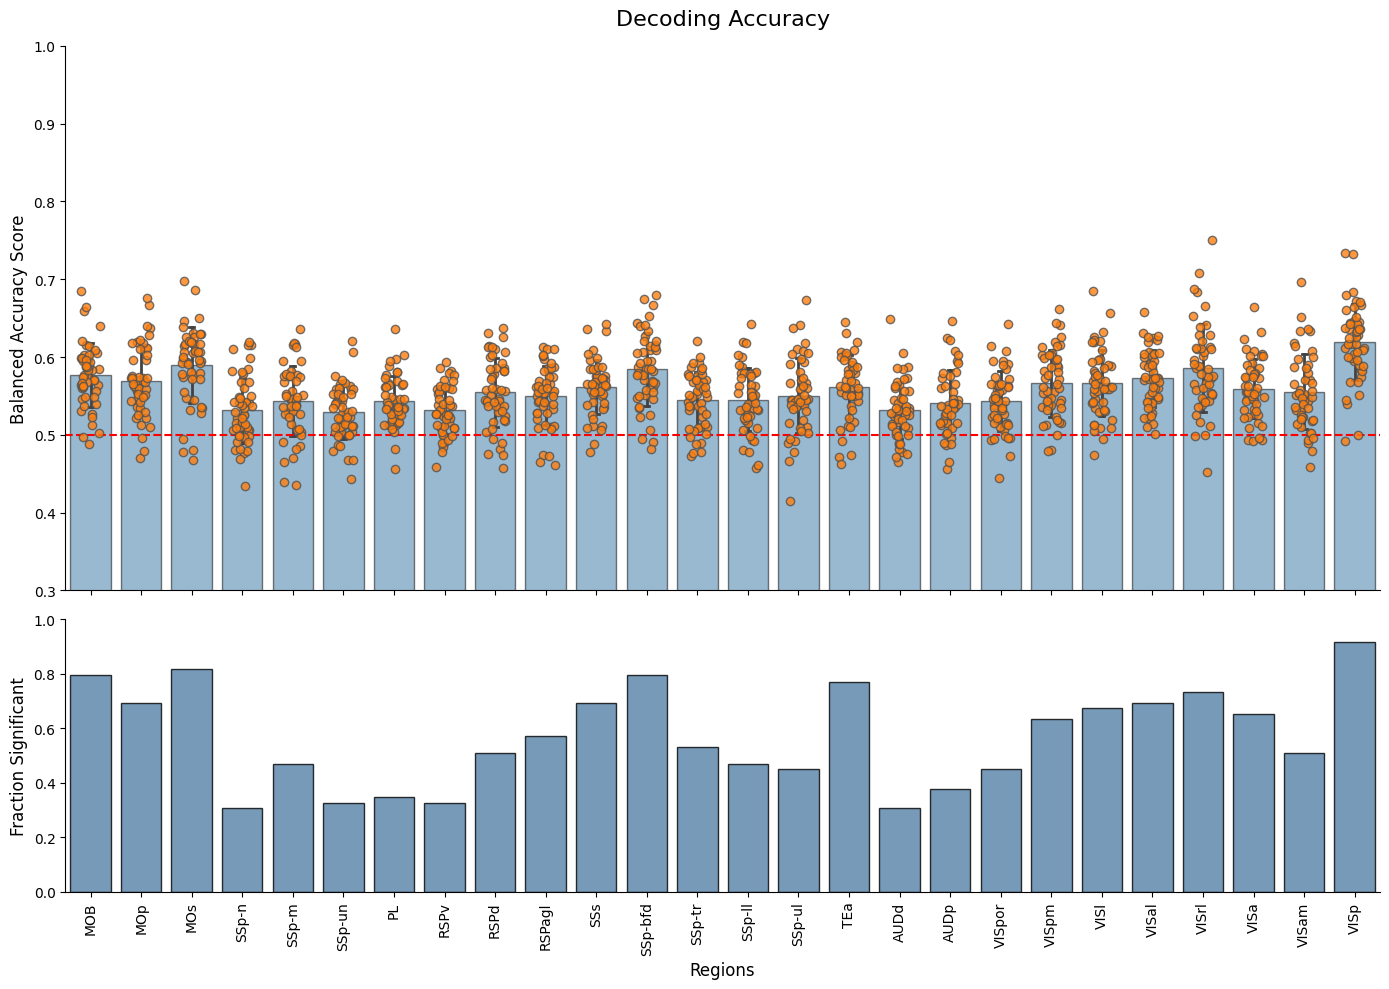

In [98]:
plot_results(df_stimulus, df_stimulus_agg)

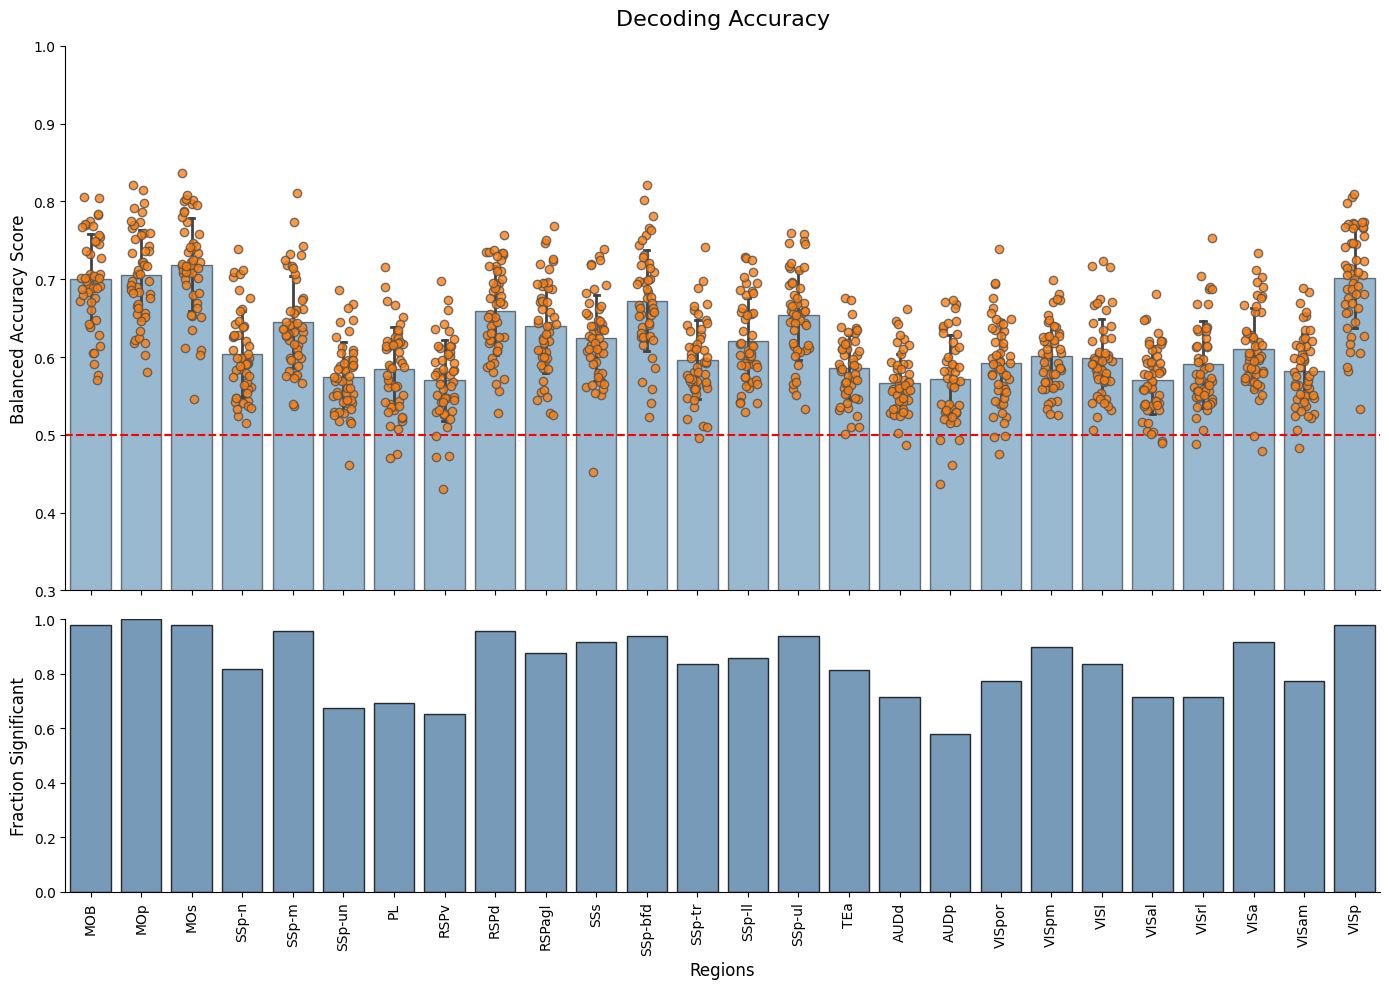

In [99]:
plot_results(df_choice, df_choice_agg)

In [110]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from iblatlas.plots import plot_scalar_on_slice

In [165]:
import matplotlib.colors as mcolors

bottom_half = plt.cm.Blues_r(np.linspace(0.5, 1.0, 128))

# Grab 128 shades of a highly visible bright gradient for the top half (0.5 to 1.0)
top_half = plt.cm.YlOrRd(np.linspace(0.0, 1.0, 128))

# Stack them together and register it as a new colormap
combined_colors = np.vstack((bottom_half, top_half))
custom_cmap = mcolors.LinearSegmentedColormap.from_list("VisibleDecoding", combined_colors)

In [171]:
def plot_topdown(regions, scores, epoch, cmap="jet"):

    # 1. Your actual regions and R2 scores

    fig, ax = plt.subplots(figsize=(6, 6))
    fig, ax, cbar = plot_scalar_on_slice(
        regions=regions,
        values=scores,
        slice="top",  # <--- This creates the orthographic top-down silhouette
        vector=True,  # <--- Forces clean polygon lines (not pixelated)
        mapping="Beryl",
        hemisphere="left",  # Forces plotting ONLY on the left hemisphere
        background="boundary",  # Draws the full black wireframe
        empty_color="white",  # Keeps un-passed regions white
        ax=ax,
        cmap=cmap,
        show_cbar=True,
        clevels=[0.0, 1],
    )

    cbar.ax.set_title("balanced accuracy", fontsize=12, pad=12)
    cbar.outline.set_visible(False)

    ax.set_title(f"WFI-{epoch}", fontsize=14, pad=15)
    ax.axis("off")

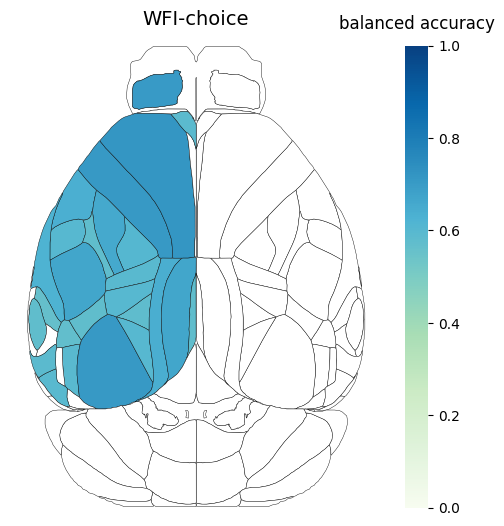

In [175]:
plot_topdown(
    regions=df_choice_agg["region"].values,
    scores=df_choice_agg["median-score"].values,
    epoch="choice",
    cmap="GnBu",
)

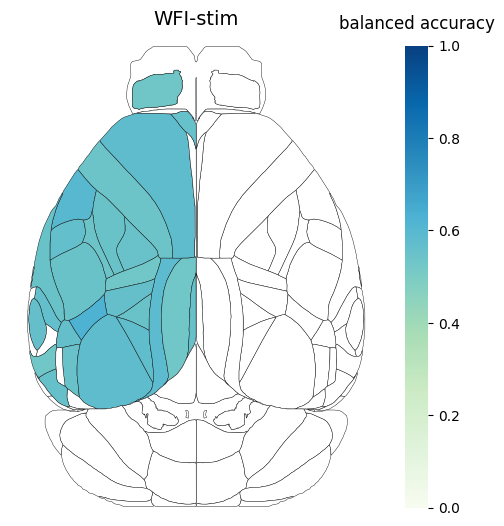

In [176]:
plot_topdown(
    regions=df_stimulus["region"].values,
    scores=df_stimulus_agg["median-score"].values,
    epoch="stim",
    cmap="GnBu",
)